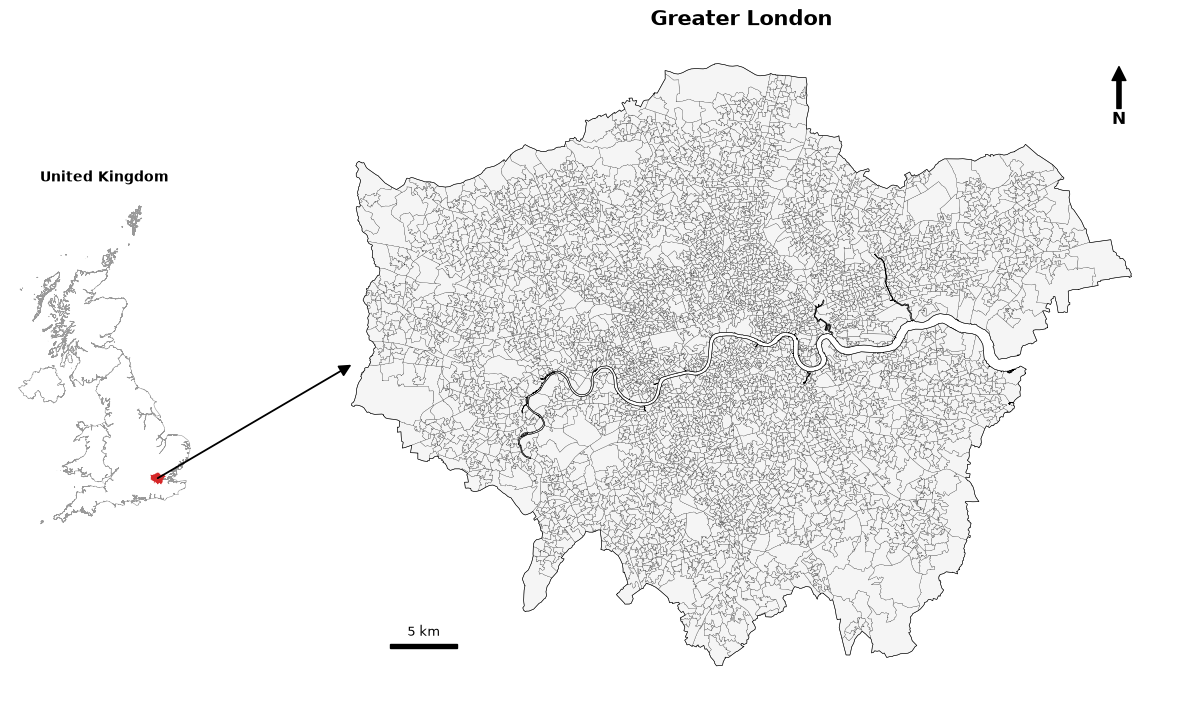

In [18]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, ConnectionPatch

BASE = "/Users/alexia/Documents/CASA/Dissertation"

lsoa_boundaries = gpd.read_file(f"{BASE}/03_data/demand/spatial/LSOA_2021_EW_BGC_V5.shp")
if lsoa_boundaries.crs is None or lsoa_boundaries.crs.to_epsg() != 27700:
    lsoa_boundaries = lsoa_boundaries.to_crs(epsg=27700)

demand = pd.read_csv(f"{BASE}/05_processed/demand_london.csv")
london_lsoa_codes = demand["lsoa_code"]
lsoa_london = lsoa_boundaries[lsoa_boundaries["LSOA21CD"].isin(london_lsoa_codes)]
london_outline = lsoa_london.dissolve()

uk_outline = gpd.read_file(f"{BASE}/03_data/demand/spatial/Countries_December_2021_UK_BGC.shp")


fig = plt.figure(figsize=(13, 10))

# ---- Greater London ----
ax_main = fig.add_axes([0.30, 0.05, 0.66, 0.85])  # [left, bottom, width, height]
lsoa_london.plot(ax=ax_main, facecolor="#f5f5f5", edgecolor="Black", linewidth=0.15)
london_outline.boundary.plot(ax=ax_main, color="Black", linewidth=0.45)
ax_main.set_axis_off()
ax_main.set_title("Greater London", fontsize=15, fontweight="bold")

# North arrow
ax_main.annotate("N", xy=(0.94, 0.95), xytext=(0.94, 0.87),
                  xycoords="axes fraction",
                  arrowprops=dict(facecolor="black", edgecolor="black", width=3, headwidth=10, headlength=10),
                  ha="center", va="center", fontsize=12, fontweight="bold")

# Scale bar
minx, miny, maxx, maxy = lsoa_london.total_bounds
bar_length_m = 5000
bar_x0 = minx + (maxx - minx) * 0.05
bar_y0 = miny + (maxy - miny) * 0.03
ax_main.add_patch(Rectangle((bar_x0, bar_y0), bar_length_m, (maxy - miny) * 0.006,
                             facecolor="black", edgecolor="black"))
ax_main.text(bar_x0 + bar_length_m / 2, bar_y0 + (maxy - miny) * 0.02, "5 km", ha="center", fontsize=9)

# ---- UK ----
axins = fig.add_axes([0.02, 0.30, 0.24, 0.35])  
uk_outline.plot(ax=axins, facecolor="white", edgecolor="#999999", linewidth=0.4)
london_outline.plot(ax=axins, facecolor="#d62728", edgecolor="none")
axins.set_axis_off()
axins.set_title("United Kingdom", fontsize=10, fontweight="bold")

# ---- point ----
uk_london_point = london_outline.geometry.iloc[0].centroid  
main_left_point = (minx, (miny + maxy) / 2) 

con = ConnectionPatch(
    xyA=(uk_london_point.x, uk_london_point.y), coordsA="data", axesA=axins,
    xyB=main_left_point, coordsB="data", axesB=ax_main,
    arrowstyle="-|>", mutation_scale=18, linewidth=1.3, color="black",
)
fig.add_artist(con)

plt.savefig(f"{BASE}/06_outputs/figures/fig_study_area_map.png", dpi=300, bbox_inches="tight")
plt.show()